# MeSH Frequency Analysis

This simple notebook analyzes Medical Subject Headings (MeSH) to characterize research themes:
- **Term frequency** — Top 50 MeSH terms by occurrence
- **Temporal trends** — Rising/falling MeSH terms over decades
- **Diversity analysis** — Are papers becoming more/less interdisciplinary?

---
## Setup

In [1]:
import sqlite3
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx
from collections import Counter
import sys
sys.path.append('../')
from utils import (
    query_db, 
    save_figure, 
    save_dataframe,
    save_figure_both_formats
)

plt.style.context(['science', 'no-latex', 'nature'])

NOTEBOOK_NAME = '02_mesh_frequency'
TIMESTAMP = datetime.now().strftime('%Y-%m-%d')
DB_PATH = Path('../../data/raw/subiculum_literature.db')
IMGS_DIR = Path('imgs')
OUTPUTS_DIR = Path('outputs')

IMGS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

## Load Data

In [2]:
conn = sqlite3.connect(DB_PATH)

# Load papers with MeSH terms
# Note: no tree_numbers
mesh_query = """
SELECT 
    p.pmid,
    p.title,
    p.journal_name,
    p.pub_year,
    m.mesh_id,
    m.descriptor_name,
    m.descriptor_ui,
    pmt.is_major_topic
FROM papers p
JOIN paper_mesh_terms pmt ON p.pmid = pmt.pmid
JOIN mesh_terms m ON pmt.mesh_id = m.mesh_id
WHERE p.pub_year IS NOT NULL
ORDER BY p.pub_year, p.pmid
"""
mesh_df = pd.read_sql_query(mesh_query, conn)

# Load papers
papers_query = """
SELECT 
    pmid,
    title,
    journal_name,
    pub_year
FROM papers
WHERE pub_year IS NOT NULL
ORDER BY pub_year
"""
papers_df = pd.read_sql_query(papers_query, conn)

conn.close()

print(f"Loaded {len(mesh_df):,} paper-MeSH relationships")
print(f"Loaded {len(papers_df):,} papers")
print(f"Unique MeSH terms: {mesh_df['mesh_id'].nunique():,}")
print(f"Year range: {mesh_df['pub_year'].min()}-{mesh_df['pub_year'].max()}")
print(f"Papers with MeSH: {mesh_df['pmid'].nunique():,} ({mesh_df['pmid'].nunique()/len(papers_df)*100:.1f}%)")

Loaded 41,613 paper-MeSH relationships
Loaded 3,572 papers
Unique MeSH terms: 3,196
Year range: 1966-2025
Papers with MeSH: 3,258 (91.2%)


---
## Part 1: Top MeSH Terms by Frequency

Identify the most frequently occurring MeSH terms across the entire corpus.

### 1.1 Calculate Term Frequencies

In [3]:
# Calculate frequency for each MeSH term
mesh_frequencies = mesh_df.groupby(['mesh_id', 'descriptor_name']).agg({
    'pmid': 'count',
    'is_major_topic': 'sum'  # Count how many times it was a major topic
}).reset_index()

mesh_frequencies.columns = ['mesh_id', 'descriptor_name', 'paper_count', 'major_topic_count']
mesh_frequencies = mesh_frequencies.sort_values('paper_count', ascending=False)

# Calculate percentages
total_papers = papers_df['pmid'].nunique()
mesh_frequencies['percentage'] = (mesh_frequencies['paper_count'] / total_papers) * 100
mesh_frequencies['major_topic_pct'] = (mesh_frequencies['major_topic_count'] / mesh_frequencies['paper_count']) * 100
mesh_frequencies['rank'] = range(1, len(mesh_frequencies) + 1)

print(f"Total unique MeSH terms: {len(mesh_frequencies):,}")
print(f"\nTop 10 MeSH terms:")
print(mesh_frequencies[['rank', 'descriptor_name', 'paper_count', 'percentage', 'major_topic_count']].head(10))

# Save full frequencies
mesh_frequencies.to_csv(OUTPUTS_DIR / f'{NOTEBOOK_NAME}_{TIMESTAMP}_mesh_frequencies.csv', index=False)
print(f"\n✓ Saved: {NOTEBOOK_NAME}_{TIMESTAMP}_mesh_frequencies.csv")

Total unique MeSH terms: 3,196

Top 10 MeSH terms:
     rank             descriptor_name  paper_count  percentage  \
5       1                 Hippocampus         2329   65.201568   
15      2                     Animals         2115   59.210526   
28      3                        Male         2058   57.614782   
6       4                      Humans         1378   38.577828   
23      5                        Rats         1285   35.974244   
41      6                      Female         1243   34.798432   
55      7                     Neurons          764   21.388578   
40      8                        Aged          594   16.629339   
116     9                       Brain          592   16.573348   
315    10  Magnetic Resonance Imaging          560   15.677492   

     major_topic_count  
5                  215  
15                   0  
28                   0  
6                    0  
23                   0  
41                   0  
55                  38  
40                   0

### 1.2 Top 50 MeSH Terms Visualization

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/02_mesh_frequency_2025-12-09_top50_mesh.png
✅ Saved EPS: imgs/02_mesh_frequency_2025-12-09_top50_mesh.eps


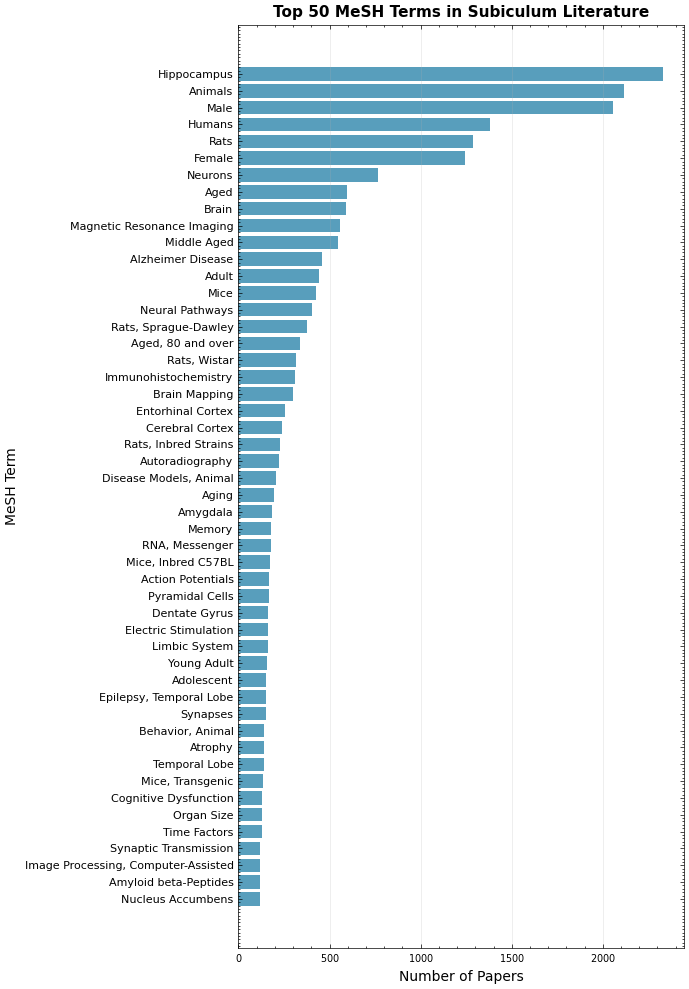

In [4]:
top50 = mesh_frequencies.head(50).copy()

with plt.style.context(['science', 'no-latex', 'nature']):
    fig, ax = plt.subplots(figsize=(7.0, 10.0))
    
    y_pos = np.arange(len(top50))
    ax.barh(y_pos, top50['paper_count'], color='#2E86AB', alpha=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top50['descriptor_name'], fontsize=8)
    ax.set_xlabel('Number of Papers', fontsize=10)
    ax.set_ylabel('MeSH Term', fontsize=10)
    ax.set_title('Top 50 MeSH Terms in Subiculum Literature', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linewidth=0.5)
    
    plt.tight_layout()
    
    filename = f'{NOTEBOOK_NAME}_{TIMESTAMP}_top50_mesh'
    save_figure_both_formats(fig, filename, IMGS_DIR)
    plt.show()

---
## Part 3: Temporal Trends in MeSH Terms

Identify which research themes are rising or falling over time.

In [5]:
mesh_df['decade'] = (mesh_df['pub_year'] // 10) * 10

top20_terms = mesh_frequencies.head(20)['mesh_id'].tolist()

temporal_data = mesh_df[mesh_df['mesh_id'].isin(top20_terms)].copy()
temporal_counts = temporal_data.groupby(['decade', 'mesh_id', 'descriptor_name'])['pmid'].count().reset_index()
temporal_counts.columns = ['decade', 'mesh_id', 'descriptor_name', 'count']

# Calculate papers per decade for normalization
papers_per_decade = papers_df.copy()
papers_per_decade['decade'] = (papers_per_decade['pub_year'] // 10) * 10
decade_totals = papers_per_decade.groupby('decade')['pmid'].count().reset_index()
decade_totals.columns = ['decade', 'total_papers']

temporal_counts = temporal_counts.merge(decade_totals, on='decade')
temporal_counts['percentage'] = (temporal_counts['count'] / temporal_counts['total_papers']) * 100

print("Temporal trends calculated for top 20 terms")
print(f"Decades covered: {temporal_counts['decade'].min()}s - {temporal_counts['decade'].max()}s")

temporal_counts.to_csv(OUTPUTS_DIR / f'{NOTEBOOK_NAME}_{TIMESTAMP}_mesh_temporal.csv', index=False)
print(f"✓ Saved: {NOTEBOOK_NAME}_{TIMESTAMP}_mesh_temporal.csv")

Temporal trends calculated for top 20 terms
Decades covered: 1960s - 2020s
✓ Saved: 02_mesh_frequency_2025-12-09_mesh_temporal.csv


✓ Saved: 02_mesh_frequency_2025-12-09_mesh_trends.html


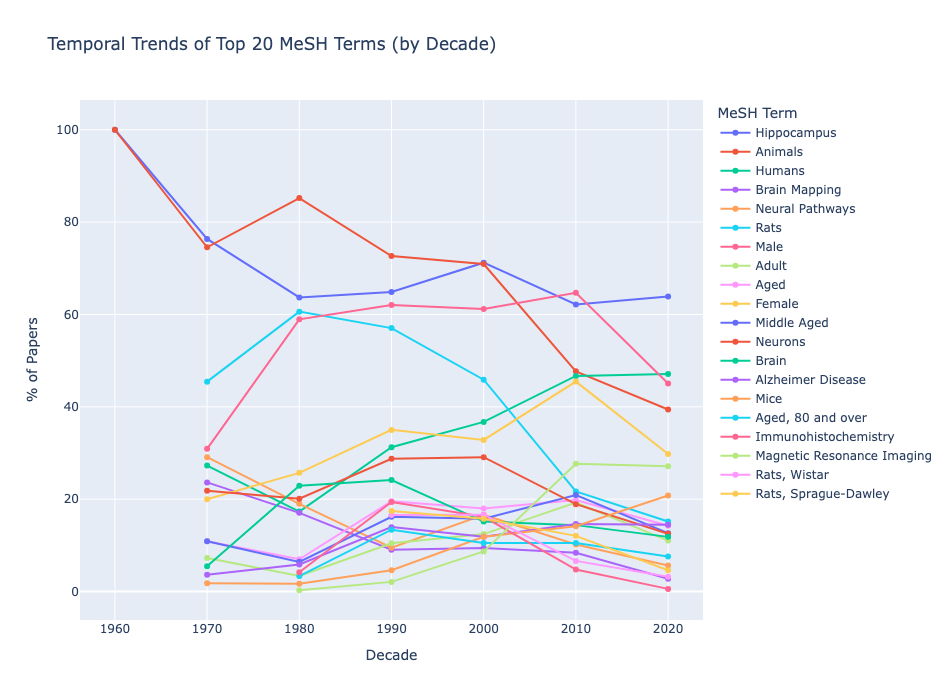

In [6]:
# Create interactive line plot with slider
fig = px.line(
    temporal_counts,
    x='decade',
    y='percentage',
    color='descriptor_name',
    title='Temporal Trends of Top 20 MeSH Terms (by Decade)',
    labels={'decade': 'Decade', 'percentage': '% of Papers', 'descriptor_name': 'MeSH Term'},
    markers=True,
    hover_data={'count': True, 'total_papers': True}
)

fig.update_layout(
    width=1200,
    height=700,
    hovermode='x unified',
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

fig.update_xaxes(tickformat='d')

fig.show()

### 3.3 Rising and Falling Terms

In [7]:
# Compare recent decade (2010s+2020s) vs older decades (pre-2010)
recent_decade = temporal_counts[temporal_counts['decade'] >= 2010].groupby('mesh_id').agg({
    'descriptor_name': 'first',
    'percentage': 'mean'
}).reset_index()
recent_decade.columns = ['mesh_id', 'descriptor_name', 'recent_pct']

older_decades = temporal_counts[temporal_counts['decade'] < 2010].groupby('mesh_id').agg({
    'descriptor_name': 'first',
    'percentage': 'mean'
}).reset_index()
older_decades.columns = ['mesh_id', 'descriptor_name', 'old_pct']

trend_comparison = recent_decade.merge(older_decades, on='mesh_id', suffixes=('', '_old'))
trend_comparison['change'] = trend_comparison['recent_pct'] - trend_comparison['old_pct']
trend_comparison['change_pct'] = (trend_comparison['change'] / trend_comparison['old_pct']) * 100

rising_terms = trend_comparison.sort_values('change', ascending=False).head(10)
falling_terms = trend_comparison.sort_values('change', ascending=True).head(10)

print("Top 10 Rising Terms (2010+ vs pre-2010):")
print(rising_terms[['descriptor_name', 'old_pct', 'recent_pct', 'change', 'change_pct']])

print("\nTop 10 Falling Terms (2010+ vs pre-2010):")
print(falling_terms[['descriptor_name', 'old_pct', 'recent_pct', 'change', 'change_pct']])

trend_comparison.to_csv(OUTPUTS_DIR / f'{NOTEBOOK_NAME}_{TIMESTAMP}_mesh_trend_changes.csv', index=False)
print(f"\n✓ Saved: {NOTEBOOK_NAME}_{TIMESTAMP}_mesh_trend_changes.csv")

Top 10 Rising Terms (2010+ vs pre-2010):
               descriptor_name    old_pct  recent_pct     change  change_pct
19  Magnetic Resonance Imaging   3.689011   27.390652  23.701641  642.493165
1                       Humans  28.141020   46.903926  18.762906   66.674578
14                        Mice   4.985187   17.481945  12.496758  250.677817
9                       Female  28.384720   37.617358   9.232638   32.526789
7                        Adult   8.382178   15.141135   6.758957   80.634858
13           Alzheimer Disease   8.823341   14.542264   5.718923   64.815844
10                 Middle Aged  12.313581   16.775379   4.461798   36.234775
8                         Aged  13.852284   17.026879   3.174595   22.917483
6                         Male  53.270302   54.884930   1.614628    3.031009
15           Aged, 80 and over   9.078610    9.047528  -0.031082   -0.342360

Top 10 Falling Terms (2010+ vs pre-2010):
         descriptor_name    old_pct  recent_pct     change  change_pc

---
## Part 4: MeSH Diversity Analysis

Examine whether papers are becoming more/less interdisciplinary over time.

### 4.1 Calculate MeSH Terms per Paper

In [11]:
mesh_per_paper = mesh_df.groupby(['pmid', 'pub_year']).agg({
    'mesh_id': 'count',
    # 'major_topic': 'sum'
}).reset_index()
mesh_per_paper.columns = ['pmid', 'pub_year', 'mesh_count']#, 'major_topic_count']

diversity_by_year = mesh_per_paper.groupby('pub_year').agg({
    'mesh_count': ['mean', 'median', 'std'],
    'pmid': 'count'
}).reset_index()
diversity_by_year.columns = ['pub_year', 'mean_mesh', 'median_mesh', 'std_mesh', 'paper_count']

mesh_per_paper['decade'] = (mesh_per_paper['pub_year'] // 10) * 10
diversity_by_decade = mesh_per_paper.groupby('decade').agg({
    'mesh_count': ['mean', 'median', 'std'],
    'pmid': 'count'
}).reset_index()
diversity_by_decade.columns = ['decade', 'mean_mesh', 'median_mesh', 'std_mesh', 'paper_count']

print("MeSH Diversity Statistics:")
print(f"Overall mean MeSH terms per paper: {mesh_per_paper['mesh_count'].mean():.2f}")
print(f"Overall median: {mesh_per_paper['mesh_count'].median():.2f}")
print(f"Overall std dev: {mesh_per_paper['mesh_count'].std():.2f}")

print("\nBy Decade:")
print(diversity_by_decade)

diversity_by_year.to_csv(OUTPUTS_DIR / f'{NOTEBOOK_NAME}_{TIMESTAMP}_mesh_diversity_yearly.csv', index=False)
diversity_by_decade.to_csv(OUTPUTS_DIR / f'{NOTEBOOK_NAME}_{TIMESTAMP}_mesh_diversity_decade.csv', index=False)
print(f"\n✓ Saved diversity statistics")

MeSH Diversity Statistics:
Overall mean MeSH terms per paper: 12.77
Overall median: 12.00
Overall std dev: 4.20

By Decade:
   decade  mean_mesh  median_mesh  std_mesh  paper_count
0    1960   5.000000          5.0       NaN            1
1    1970  10.166667         10.0  3.014118           54
2    1980  11.550847         11.0  3.232968          354
3    1990  13.123055         13.0  3.678337          707
4    2000  14.437026         14.0  4.663793          659
5    2010  13.570707         13.0  4.106367          792
6    2020  10.752533         10.0  3.767651          691

✓ Saved diversity statistics


### 4.2 Visualize Diversity Trends

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved PNG: imgs/02_mesh_frequency_2025-12-09_mesh_diversity_trend.png
✅ Saved EPS: imgs/02_mesh_frequency_2025-12-09_mesh_diversity_trend.eps


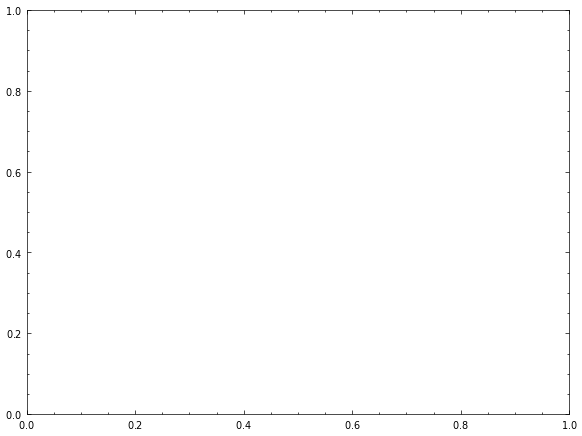

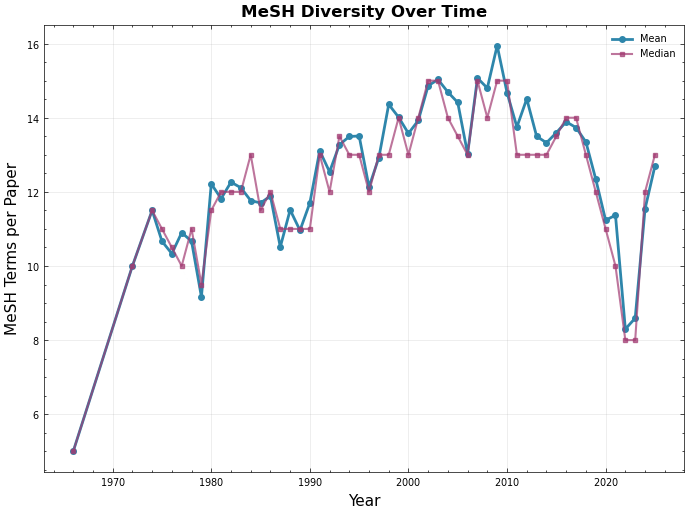

In [12]:
with plt.style.context(['science', 'no-latex', 'nature']):
    fig, ax = plt.subplots(figsize=(7.0, 5.25))
    
    ax.plot(diversity_by_year['pub_year'], diversity_by_year['mean_mesh'], 
            marker='o', markersize=4, linewidth=2, color='#2E86AB', label='Mean')
    ax.plot(diversity_by_year['pub_year'], diversity_by_year['median_mesh'], 
            marker='s', markersize=3, linewidth=1.5, color='#A23B72', alpha=0.7, label='Median')
    
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('MeSH Terms per Paper', fontsize=11)
    ax.set_title('MeSH Diversity Over Time', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3, linewidth=0.5)
    
    plt.tight_layout()
    
    filename = f'{NOTEBOOK_NAME}_{TIMESTAMP}_mesh_diversity_trend'
    save_figure_both_formats(fig, filename, IMGS_DIR)
    plt.show()

---
## Part 5: Summary Statistics

Export comprehensive summary for reproducibility.

In [13]:
summary = {
    'metadata': {
        'analysis_date': TIMESTAMP,
        'database': str(DB_PATH),
        'total_papers': int(total_papers),
        'papers_with_mesh': int(mesh_df['pmid'].nunique()),
        'mesh_coverage_pct': float(mesh_df['pmid'].nunique() / total_papers * 100)
    },
    'mesh_terms': {
        'total_unique_terms': int(len(mesh_frequencies)),
        'total_paper_mesh_pairs': int(len(mesh_df)),
        'avg_terms_per_paper': float(mesh_per_paper['mesh_count'].mean()),
        'median_terms_per_paper': float(mesh_per_paper['mesh_count'].median()),
        'top_10_terms': [
            {
                'rank': int(row['rank']),
                'mesh_id': str(row['mesh_id']),
                'descriptor': str(row['descriptor_name']),
                'paper_count': int(row['paper_count']),
                'percentage': float(row['percentage']),
                'major_topic_count': int(row['major_topic_count'])
            }
            for _, row in mesh_frequencies.head(10).iterrows()
        ]
    },
    'temporal_trends': {
        'year_range': f"{mesh_df['pub_year'].min()}-{mesh_df['pub_year'].max()}",
        'diversity_trend': {
            'earliest_decade_mean': float(diversity_by_decade.iloc[0]['mean_mesh']),
            'latest_decade_mean': float(diversity_by_decade.iloc[-1]['mean_mesh']),
            'change': float(diversity_by_decade.iloc[-1]['mean_mesh'] - diversity_by_decade.iloc[0]['mean_mesh'])
        }
    }
}

with open(OUTPUTS_DIR / f'{NOTEBOOK_NAME}_{TIMESTAMP}_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Summary Statistics:")
print(json.dumps(summary, indent=2))
print(f"\n✓ Saved: {NOTEBOOK_NAME}_{TIMESTAMP}_summary.json")

Summary Statistics:
{
  "metadata": {
    "analysis_date": "2025-12-09",
    "database": "../../data/raw/subiculum_literature.db",
    "total_papers": 3572,
    "papers_with_mesh": 3258,
    "mesh_coverage_pct": 91.2094064949608
  },
  "mesh_terms": {
    "total_unique_terms": 3196,
    "total_paper_mesh_pairs": 41613,
    "avg_terms_per_paper": 12.77255985267035,
    "median_terms_per_paper": 12.0,
    "top_10_terms": [
      {
        "rank": 1,
        "mesh_id": "6",
        "descriptor": "Hippocampus",
        "paper_count": 2329,
        "percentage": 65.20156774916013,
        "major_topic_count": 215
      },
      {
        "rank": 2,
        "mesh_id": "16",
        "descriptor": "Animals",
        "paper_count": 2115,
        "percentage": 59.210526315789465,
        "major_topic_count": 0
      },
      {
        "rank": 3,
        "mesh_id": "32",
        "descriptor": "Male",
        "paper_count": 2058,
        "percentage": 57.6147816349384,
        "major_topic_count":

---
## Conclusions

1. **Dominant themes**: Top MeSH terms seem to reflect some core research areas
2. **Temporal shifts**: Tracking rising/falling terms shows some evolving research priorities
3. **Interdisciplinarity**: MeSH diversity metrics indicate smallish trend toward more/less specialized research